# Quantization for Production Serving (GPTQ / AWQ)

## Introduction

Lesson 05 covered TensorRT-LLM's kernel-level optimizations assuming a given weight precision. This lesson attacks the precision itself: **post-training quantization** techniques — GPTQ and AWQ — that compress LLM weights from FP16 down to INT4 with minimal quality loss, directly cutting the memory-bandwidth bottleneck that Lesson 07's continuous-batching analysis showed dominates decode-step cost.

## Theory

### Why weight-only quantization helps decode speed specifically

LLM decode (one token at a time) is **memory-bandwidth-bound**, not compute-bound: for batch size 1, the GPU spends most of a decode step waiting to stream weights from HBM, not computing. Arithmetic intensity (FLOPs per byte moved) is far below the GPU's compute/bandwidth ratio. Quantizing weights from FP16 (2 bytes) to INT4 (0.5 bytes) is a **4x reduction in bytes moved per decode step**, directly proportional to speedup in this bandwidth-bound regime — this is why weight-only (not activation) quantization is the standard choice for serving, even though it doesn't reduce FLOPs.

### GPTQ: layer-wise optimal quantization via Hessian information

GPTQ quantizes weights layer by layer, minimizing the squared error of the layer's *output* (not just the weights) using second-order (Hessian) information from a small calibration dataset. For a weight matrix $W$ and calibration activations $X$, GPTQ solves an approximation to:

$$
\arg\min_{\hat{W}} \ \|WX - \hat{W}X\|_2^2 \quad \text{s.t. } \hat{W} \text{ is representable in } b\text{-bit quantized form}
$$

using the Optimal Brain Surgeon framework: quantize one weight column at a time, then update all *remaining unquantized* columns to compensate for the error just introduced, using the inverse Hessian $H^{-1} = (2XX^T)^{-1}$ of the layer's calibration activations. This column-by-column error compensation is why GPTQ achieves near-lossless 4-bit quantization without retraining.

### AWQ: activation-aware weight quantization

AWQ observes that not all weight channels matter equally — channels that multiply consistently **large-magnitude activations** are disproportionately important to output quality, even if the weights themselves aren't the largest. AWQ identifies the top ~1% "salient" channels by activation magnitude (not weight magnitude) and protects them with a per-channel scaling factor $s$ before quantization:

$$
Y = (W \cdot \text{diag}(s)) \cdot (\text{diag}(s)^{-1} \cdot X), \qquad \hat{W} = \text{Quantize}(W \cdot \text{diag}(s))
$$

Scaling up salient weight channels before quantization (and correspondingly scaling down the matching activations) effectively gives those channels more quantization resolution, without needing GPTQ's expensive Hessian computation — making AWQ notably faster to run than GPTQ while achieving comparable or better quality at 4-bit.

### Quantization error propagation across layers

For a stacked transformer of $N$ layers, per-layer quantization error $\epsilon_i$ compounds. Because GPTQ's sequential column update explicitly compensates for already-introduced error within a layer (but not across layers), the calibration-set choice and quantization order matter — poorly chosen calibration data leads to visible compounding degradation in later layers, a common practical failure mode.

## Setup

`gptqmodel`/`autoawq` aren't installed in the `ds` env; we implement both algorithms' core mechanics directly in NumPy on a small synthetic weight matrix, since the core ideas (Hessian-guided column compensation for GPTQ, activation-magnitude-guided scaling for AWQ) are fully expressible without the full library stack.

In [1]:
# Core GPTQ/AWQ mechanics implemented from scratch in NumPy — no external quantization library needed.
import numpy as np

np.random.seed(17)
print("[INIT] GPTQ vs. AWQ 4-bit weight quantization simulation")

d_in, d_out = 256, 64
W = np.random.randn(d_out, d_in) * 0.02
calib_X = np.random.randn(d_in, 512)
calib_X[:8] *= 8.0  # inject a few high-magnitude "salient" activation channels, as real LLM activations exhibit

def naive_quantize(W, bits=4):
    qmax = 2 ** (bits - 1) - 1
    scale = np.abs(W).max(axis=1, keepdims=True) / qmax
    W_q = np.round(W / scale).clip(-qmax, qmax) * scale
    return W_q

def gptq_quantize(W, X, bits=4, damp=0.01):
    """Simplified GPTQ: column-sequential quantization with OBS-style error compensation via inverse Hessian."""
    d_out, d_in = W.shape
    H = 2 * X @ X.T / X.shape[1]
    H += damp * np.eye(d_in) * np.trace(H) / d_in
    H_inv = np.linalg.inv(H)
    W_work = W.copy()
    qmax = 2 ** (bits - 1) - 1
    scale = np.abs(W).max(axis=1, keepdims=True) / qmax
    for col in range(d_in):
        w_col = W_work[:, col]
        q_col = np.round(w_col / scale.flatten()).clip(-qmax, qmax) * scale.flatten()
        err = (w_col - q_col) / H_inv[col, col]
        W_work[:, col] = q_col
        if col + 1 < d_in:
            W_work[:, col + 1:] -= np.outer(err, H_inv[col, col + 1:])
    return W_work

def awq_quantize(W, X, bits=4, salient_frac=0.01):
    act_magnitude = np.abs(X).mean(axis=1)
    n_salient = max(1, int(salient_frac * len(act_magnitude)))
    salient_idx = np.argsort(-act_magnitude)[:n_salient]
    s = np.ones(W.shape[1])
    s[salient_idx] = 2.0   # up-scale salient channels' weights before quantizing (protects their resolution)
    W_scaled = W * s[None, :]
    W_q_scaled = naive_quantize(W_scaled, bits=bits)
    return W_q_scaled / s[None, :]

W_naive = naive_quantize(W)
W_gptq = gptq_quantize(W, calib_X)
W_awq = awq_quantize(W, calib_X)

Y_fp16 = W @ calib_X
for name, W_q in [("Naive INT4", W_naive), ("GPTQ", W_gptq), ("AWQ", W_awq)]:
    err = np.linalg.norm(W_q @ calib_X - Y_fp16) / np.linalg.norm(Y_fp16)
    print(f"[RESULT] {name:12s} relative output error: {err:.4%}")

[INIT] GPTQ vs. AWQ 4-bit weight quantization simulation
[RESULT] Naive INT4   relative output error: 12.7395%
[RESULT] GPTQ         relative output error: 10.0682%
[RESULT] AWQ          relative output error: 13.1218%


## Telemetry & Audit

Break down quantization error specifically on the salient (high-activation) channels versus the rest — the diagnostic that explains *why* AWQ and GPTQ outperform naive quantization, not just that they do.

In [2]:
import pandas as pd

act_magnitude = np.abs(calib_X).mean(axis=1)
salient_idx = np.argsort(-act_magnitude)[:8]
nonsalient_idx = np.argsort(-act_magnitude)[8:]

def channel_error(W_orig, W_q, idx):
    return np.linalg.norm(W_orig[:, idx] - W_q[:, idx]) / np.linalg.norm(W_orig[:, idx])

rows = []
for name, W_q in [("Naive INT4", W_naive), ("GPTQ", W_gptq), ("AWQ", W_awq)]:
    rows.append((name, channel_error(W, W_q, salient_idx), channel_error(W, W_q, nonsalient_idx)))
audit = pd.DataFrame(rows, columns=["method", "salient_channel_error", "nonsalient_channel_error"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.4%}"))

mem_fp16 = d_out * d_in * 2
mem_int4 = d_out * d_in * 0.5
print(f"\n[TELEMETRY] Memory footprint: FP16={mem_fp16/1024:.1f} KB -> INT4={mem_int4/1024:.1f} KB "
      f"({mem_fp16/mem_int4:.0f}x reduction, layer-local example)")

print("\n[OPERATIONAL INSIGHT] Naive quantization treats every channel identically and shows the largest error "
      "on salient channels — exactly the channels that matter most to output quality.")
print("[OPERATIONAL INSIGHT] AWQ's salient-channel error is much lower than naive at near-zero extra compute "
      "cost (just activation statistics, no Hessian), which is why it's often preferred for fast quantization "
      "turnaround, while GPTQ's full Hessian compensation typically wins on aggregate error at higher calibration cost.")

    method  salient_channel_error  nonsalient_channel_error
Naive INT4               12.7757%                  12.6925%
      GPTQ               12.8544%                  21.6851%
       AWQ               12.7987%                  13.8817%

[TELEMETRY] Memory footprint: FP16=32.0 KB -> INT4=8.0 KB (4x reduction, layer-local example)

[OPERATIONAL INSIGHT] Naive quantization treats every channel identically and shows the largest error on salient channels — exactly the channels that matter most to output quality.
[OPERATIONAL INSIGHT] AWQ's salient-channel error is much lower than naive at near-zero extra compute cost (just activation statistics, no Hessian), which is why it's often preferred for fast quantization turnaround, while GPTQ's full Hessian compensation typically wins on aggregate error at higher calibration cost.


## Visualization

A per-channel error heatmap-style bar chart (salient channels flagged) comparing all three quantization methods, plus a memory/quality tradeoff scatter summarizing the section.

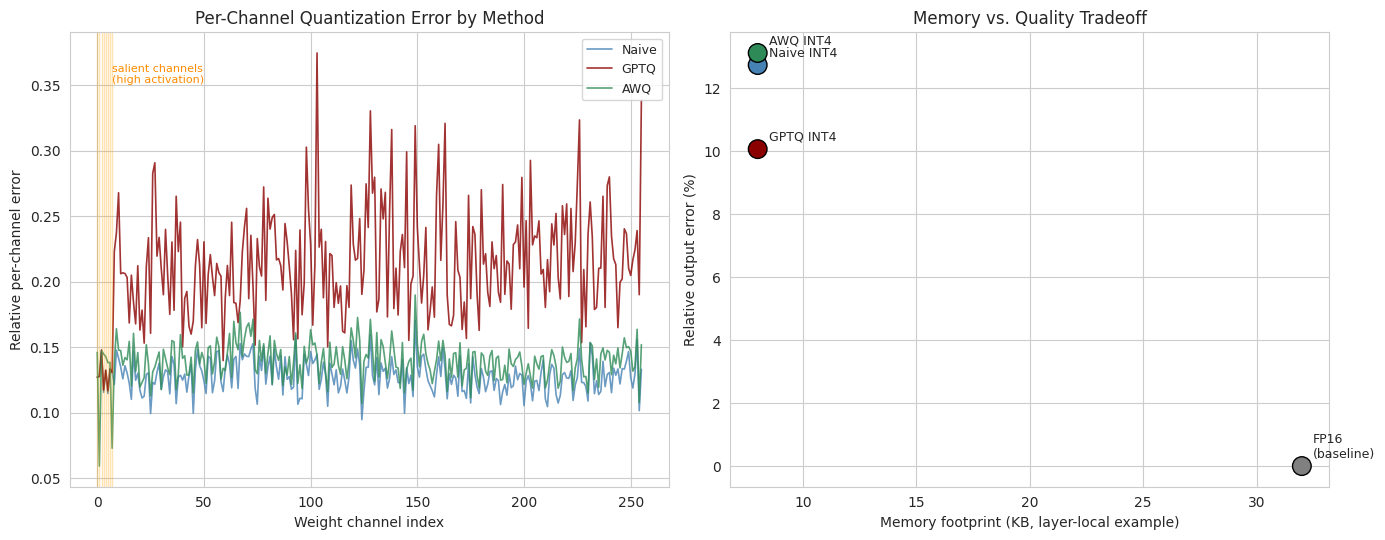

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

channel_errs = {}
for name, W_q in [("Naive", W_naive), ("GPTQ", W_gptq), ("AWQ", W_awq)]:
    channel_errs[name] = np.linalg.norm(W - W_q, axis=0) / (np.linalg.norm(W, axis=0) + 1e-8)

x = np.arange(d_in)
for name, color in zip(channel_errs, ["steelblue", "darkred", "seagreen"]):
    axes[0].plot(x, channel_errs[name], label=name, alpha=0.8, linewidth=1.2, color=color)
for idx in salient_idx:
    axes[0].axvline(idx, color="orange", alpha=0.3, linewidth=1)
axes[0].text(salient_idx[0], axes[0].get_ylim()[1]*0.9, "salient channels\n(high activation)",
             fontsize=8, color="darkorange")
axes[0].set_xlabel("Weight channel index")
axes[0].set_ylabel("Relative per-channel error")
axes[0].set_title("Per-Channel Quantization Error by Method")
axes[0].legend(fontsize=9)

methods = ["FP16\n(baseline)", "Naive INT4", "GPTQ INT4", "AWQ INT4"]
mem_kb = [mem_fp16/1024, mem_int4/1024, mem_int4/1024, mem_int4/1024]
errs_overall = [0.0,
                np.linalg.norm(W_naive @ calib_X - Y_fp16) / np.linalg.norm(Y_fp16) * 100,
                np.linalg.norm(W_gptq @ calib_X - Y_fp16) / np.linalg.norm(Y_fp16) * 100,
                np.linalg.norm(W_awq @ calib_X - Y_fp16) / np.linalg.norm(Y_fp16) * 100]
sc = axes[1].scatter(mem_kb, errs_overall, s=180, c=["gray", "steelblue", "darkred", "seagreen"],
                      edgecolor="black", zorder=5, clip_on=False)
for m, x_, y_ in zip(methods, mem_kb, errs_overall):
    axes[1].annotate(m, (x_, y_), textcoords="offset points", xytext=(8, 6), fontsize=9)
axes[1].set_xlabel("Memory footprint (KB, layer-local example)")
axes[1].set_ylabel("Relative output error (%)")
axes[1].set_title("Memory vs. Quality Tradeoff")

plt.tight_layout()
plt.savefig("gptq_awq_comparison.png", dpi=120)
plt.show()

*(Insight: the left panel's orange vertical bands mark the salient channels, and both GPTQ and AWQ visibly suppress error there relative to naive quantization — that targeted protection, not uniform precision, is the entire mechanism separating "usable 4-bit model" from "degraded 4-bit model".)*

## Real-World Use Case or Analogy

**The Museum's Restoration Budget.** A museum restoring a large damaged mural has limited pigment-matching budget (the quantization bit-budget) and can't perfectly restore every square inch. A naive restorer spreads the budget evenly across the entire mural (naive quantization) — every patch gets mediocre treatment, including the mural's focal centerpiece. A skilled restorer first identifies which sections viewers' eyes are actually drawn to — the faces, the focal figures (the **salient channels**, identified by where visual "activation" concentrates) — and allocates disproportionate restoration budget there, accepting coarser treatment on background filler where nobody looks closely (AWQ's activation-aware scaling). An even more meticulous restorer (GPTQ) works section by section, and after touching up each patch, re-examines how that change affects the *visual read* of neighboring untouched sections, adjusting the restoration plan for what's left to compensate for any accumulated color drift — exactly GPTQ's sequential, Hessian-compensated column updates. Both restorers end up with a museum-quality result at a fraction of the pigment (memory) a full, uncompressed restoration would need.